# E-Scooter — Modèle Linéaire (Biogeme)
## Variable dépendante : `speed_kmh` (vitesse instantanée)


## 1 · Imports & configuration

In [38]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os, shutil, re

import biogeme.biogeme as bio
import biogeme.database as db
import biogeme.expressions as ex
from biogeme.expressions import Beta, Variable, Numeric, log, exp
import biogeme.models as models
from biogeme.parameters import Parameters
from biogeme.distributions import normal_logpdf

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

DATASET_PATH = '/Volumes/My Passport/NEWMOB/clean_dataset.csv'
FPS          = 30
COLOR_A      = '#2E86AB'
COLOR_B      = '#E84855'

## 2 · Chargement du dataset

In [39]:
df_raw = pd.read_csv(DATASET_PATH)
print(f'Dataset brut : {df_raw.shape[0]:,} lignes x {df_raw.shape[1]} colonnes')
print(f'Trajets      : {df_raw["source"].nunique()}')
display(df_raw.head(4))
print()
print('Valeurs manquantes :')
display(df_raw.isna().sum().to_frame('n_missing'))

Dataset brut : 346,426 lignes x 61 colonnes
Trajets      : 25


,source,frame,speed_kmh,gyrz_deg_s,n_vru_total,n_pedestrians,n_cyclists,n_escooters,prop_vru_pedestrian,prop_vru_cyclist,...,pct_stationary,pct_gait_standing,pct_gait_walking,pct_gait_running,pct_gait_unknown,pct_age_child,pct_age_adult,pct_age_elderly,pct_age_unknown,pct_unknown_interaction
0,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1.0,0.0,...,22.2,25.9,63.0,0.0,11.1,7.4,85.2,7.4,0.0,0.0
1,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1.0,0.0,...,22.2,25.9,63.0,0.0,11.1,7.4,85.2,7.4,0.0,0.0
2,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1.0,0.0,...,22.2,25.9,63.0,0.0,11.1,7.4,85.2,7.4,0.0,0.0
3,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1.0,0.0,...,22.2,25.9,63.0,0.0,11.1,7.4,85.2,7.4,0.0,0.0



Valeurs manquantes :


,n_missing
source,0
frame,0
speed_kmh,6184
gyrz_deg_s,6184
n_vru_total,0
...,...
pct_age_child,0
pct_age_adult,0
pct_age_elderly,0
pct_age_unknown,0


## 3 · Réduction à 1 Hz

Le dataset est échantillonné à 30 FPS. On regroupe par **seconde** (`second = frame // 30`) :

| Variable | Agrégation | Justification |
|----------|-----------|---------------|
| `speed_kmh` | `mean` | vitesse représentative |
| `n_pedestrians` | `max` | situation la plus contraignante |
| `road_width_perp_m` | `mean` | caractéristique stable |

In [40]:
df_raw['second'] = df_raw['frame'] // FPS

df_1hz = (
    df_raw
    .groupby(['source', 'second'])
    .agg(
        speed_kmh                           = ('speed_kmh',                          'mean'),
        n_pedestrians                       = ('n_pedestrians',                       'max'),
        n_cyclists                           = ('n_cyclists',                           'max'),
        road_width_perp_m                   = ('road_width_perp_m',                   'mean'),
        hour                                = ('hour',                                'first'),
        day_of_week                         = ('day_of_week',                         'first'),
        day_name                            = ('day_name',                            'first'),
        is_weekend                          = ('is_weekend',                          'first'),
        time_of_day                         = ('time_of_day',                         'first'),
        month                               = ('month',                               'first'),
        season                              = ('season',                              'first'),
        genre                               = ('genre',                               'first'),
        age                                 = ('age',                                 'first'),
        experience                          = ('experience',                          'first'),
        distance_km                         = ('distance_km',                         'first'),
        prop_vru_pedestrian                 = ('prop_vru_pedestrian',                 'first'),
        prop_vru_cyclist                    = ('prop_vru_cyclist',                    'first'),
        prop_interaction_same_direction     = ('prop_interaction_same_direction',     'max'),
        prop_interaction_opposite_direction = ('prop_interaction_opposite_direction', 'max'),
        prop_interaction_crossing           = ('prop_interaction_crossing',           'max'),
        prop_interaction_stationary         = ('prop_interaction_stationary',         'max'),
    )
    .reset_index()
    .sort_values(['source', 'second'])
    .reset_index(drop=True)
)

# Créer la vitesse à t+1
df_1hz['speed_kmh_t1'] = df_1hz.groupby('source')['speed_kmh'].shift(-1)

print(f'Après réduction 1 Hz + t+1 : {len(df_1hz):,} secondes — {df_1hz["source"].nunique()} trajets')
display(df_1hz.describe().round(2))

Après réduction 1 Hz + t+1 : 1,271 secondes — 25 trajets


,second,speed_kmh,n_pedestrians,n_cyclists,road_width_perp_m,hour,day_of_week,month,age,distance_km,prop_vru_pedestrian,prop_vru_cyclist,prop_interaction_same_direction,prop_interaction_opposite_direction,prop_interaction_crossing,prop_interaction_stationary,speed_kmh_t1
count,1271.00,1242.00,1271.00,1271.00,1206.00,1271.00,1271.00,1271.00,1271.00,1271.00,1271.00,1271.00,1271.00,1271.00,1271.00,1271.00,1218.00
mean,52.50,14.85,3.39,0.18,16.90,10.66,3.15,6.83,37.79,143.82,0.89,0.11,0.46,0.44,0.15,0.11,14.90
std,45.67,7.52,2.78,0.43,13.75,3.56,1.43,2.36,12.45,90.17,0.29,0.29,0.41,0.40,0.31,0.25,7.56
min,0.00,2.02,0.00,0.00,0.04,5.00,0.00,4.00,21.00,10.00,0.00,0.00,0.00,0.00,0.00,0.00,2.02
25%,15.50,9.29,1.00,0.00,8.34,6.00,2.00,5.00,29.00,55.69,1.00,0.00,0.00,0.00,0.00,0.00,9.29
50%,39.00,12.13,3.00,0.00,11.16,10.00,3.00,6.00,30.00,142.27,1.00,0.00,0.50,0.50,0.00,0.00,12.15
75%,77.00,20.71,5.00,0.00,22.65,13.00,4.00,10.00,53.00,239.34,1.00,0.00,1.00,0.83,0.10,0.00,20.91
max,202.00,33.85,14.00,3.00,102.76,20.00,6.00,10.00,55.00,323.21,1.00,1.00,1.00,1.00,1.00,1.00,33.85


## 4 · Variable dépendante : `speed_kmh`

**Définition :** La variable dépendante est directement `speed_kmh` (vitesse instantanée en km/h).

> **Différence clé avec le notebook logit :** On ne crée plus de variable binaire `choice`.
> On modélise directement la **vitesse continue**.

Observations totales : 1,175
  Vitesse moyenne : 15.08 km/h
  Vitesse médiane : 12.26 km/h
  Écart-type      : 7.61 km/h
  Min / Max       : 2.36 / 33.85 km/h


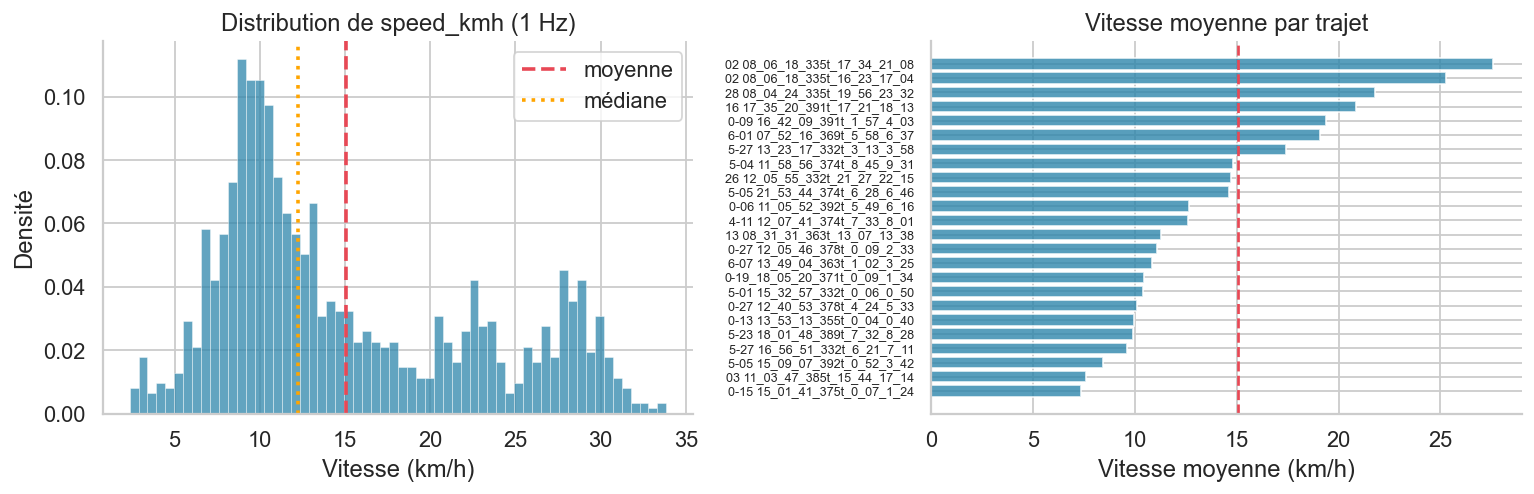

In [41]:
df_model = df_1hz.dropna(subset=['speed_kmh_t1', 'n_pedestrians', 'road_width_perp_m']).copy()

print(f'Observations totales : {len(df_model):,}')
print(f'  Vitesse moyenne : {df_model["speed_kmh_t1"].mean():.2f} km/h')
print(f'  Vitesse médiane : {df_model["speed_kmh_t1"].median():.2f} km/h')
print(f'  Écart-type      : {df_model["speed_kmh_t1"].std():.2f} km/h')
print(f'  Min / Max       : {df_model["speed_kmh_t1"].min():.2f} / {df_model["speed_kmh_t1"].max():.2f} km/h')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(df_model['speed_kmh_t1'], bins=60, color=COLOR_A, alpha=0.75,
        edgecolor='white', lw=0.3, density=True)
ax.axvline(df_model['speed_kmh_t1'].mean(), color=COLOR_B, lw=2, ls='--', label='moyenne')
ax.axvline(df_model['speed_kmh_t1'].median(), color='orange', lw=2, ls=':', label='médiane')
ax.set_xlabel('Vitesse (km/h)')
ax.set_ylabel('Densité')
ax.set_title('Distribution de speed_kmh (1 Hz)')
ax.legend()

ax = axes[1]
speed_by_traj = df_model.groupby('source')['speed_kmh_t1'].mean().sort_values()
ax.barh(range(len(speed_by_traj)), speed_by_traj.values, color=COLOR_A, alpha=0.8)
ax.axvline(df_model['speed_kmh_t1'].mean(), color=COLOR_B, lw=1.5, ls='--')
ax.set_yticks(range(len(speed_by_traj)))
ax.set_yticklabels([s[-28:] for s in speed_by_traj.index], fontsize=7)
ax.set_xlabel('Vitesse moyenne (km/h)')
ax.set_title('Vitesse moyenne par trajet')
plt.tight_layout()
plt.show()

## 5 · Standardisation & création de dummies

**Variables standardisées** (`z = (x - mu) / sigma`) : coefficients comparables entre eux.

> **Note :** La variable dépendante `speed_kmh` est conservée en unités originales (km/h).
> Les coefficients s'interprètent comme : *une augmentation d'un écart-type de X est associée à une variation de beta km/h de la vitesse*.

In [42]:
# ── Variables continues à standardiser ──────────────────────────────────────
cont_vars = ['n_pedestrians', 'n_cyclists', 'road_width_perp_m', 'hour', 'age', 'distance_km']
cont_vars = [v for v in cont_vars
             if v in df_model.columns and df_model[v].notna().any()]

means_ = df_model[cont_vars].mean()
stds_  = df_model[cont_vars].std()

for v in cont_vars:
    if pd.notna(stds_[v]) and stds_[v] != 0:
        df_model[f'z_{v}'] = (df_model[v] - means_[v]) / stds_[v]
    else:
        df_model[f'z_{v}'] = 0.0
        print(f'  ⚠  {v} a un écart-type nul')

print('Statistiques des z-scores :')
display(df_model[[f'z_{v}' for v in cont_vars]].describe().round(3))

# ── Variables catégorielles ──────────────────────────────────────────────────
exclude_from_cat = set(cont_vars)
exclude_from_cat.update([f'z_{v}' for v in cont_vars])
exclude_from_cat.update(['source', 'speed_kmh_t1', 'second'])

candidate_cat_vars = [c for c in df_model.columns if c not in exclude_from_cat]

cat_vars = []
for col in candidate_cat_vars:
    s = df_model[col]
    if s.notna().sum() == 0:
        continue
    if (pd.api.types.is_object_dtype(s)
            or pd.api.types.is_categorical_dtype(s)
            or pd.api.types.is_bool_dtype(s)):
        cat_vars.append(col)
    elif pd.api.types.is_numeric_dtype(s) and s.dropna().nunique() <= 10:
        cat_vars.append(col)

print('\nVariables catégorielles détectées :', cat_vars)

categorical_dummy_cols = []
ref_levels = {}

for col in cat_vars:
    s = df_model[col]
    if s.notna().sum() == 0:
        continue
    vc = s.value_counts(dropna=True)
    if vc.empty:
        continue
    ref = vc.index[0]
    ref_levels[col] = ref
    uniq = s.dropna().unique().tolist()
    remaining = sorted([v for v in uniq if v != ref])
    cats = [ref] + remaining
    dummies = pd.get_dummies(
        pd.Categorical(s, categories=cats, ordered=False),
        prefix=col, drop_first=True
    ).astype(int)
    df_model = pd.concat(
        [df_model.reset_index(drop=True), dummies.reset_index(drop=True)],
        axis=1
    )
    categorical_dummy_cols.extend(dummies.columns.tolist())
    print(f'  {col:20s} → {len(dummies.columns)} dummies  (réf = {ref!r})')

print(f'\nDummies catégorielles ajoutés : {len(categorical_dummy_cols)}')
print(f'Total lignes : {df_model.shape[0]}')

Statistiques des z-scores :


,z_n_pedestrians,z_n_cyclists,z_road_width_perp_m,z_hour,z_age,z_distance_km
count,1175.000,1175.000,1175.000,1175.000,1175.000,1175.000
mean,-0.000,0.000,0.000,-0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.237,-0.431,-1.221,-1.550,-1.327,-1.466
25%,-0.883,-0.431,-0.618,-1.268,-0.683,-1.001
50%,-0.173,-0.431,-0.416,-0.141,-0.603,0.017
75%,0.537,-0.431,0.420,0.704,1.409,1.058
max,3.731,6.357,6.238,2.677,1.409,2.046



Variables catégorielles détectées : ['day_of_week', 'day_name', 'is_weekend', 'time_of_day', 'month', 'season', 'genre', 'experience']
  day_of_week          → 6 dummies  (réf = np.int64(4))
  day_name             → 6 dummies  (réf = 'Friday')
  is_weekend           → 1 dummies  (réf = np.False_)
  time_of_day          → 3 dummies  (réf = 'Morning')
  month                → 3 dummies  (réf = np.int64(10))
  season               → 2 dummies  (réf = 'Spring')
  genre                → 1 dummies  (réf = 'male')
  experience           → 3 dummies  (réf = '>2')

Dummies catégorielles ajoutés : 25
Total lignes : 1175


## 6 · Création des Variables et Betas Biogeme

In [43]:
def normalize(name: str) -> str:
    clean = name.lower()
    clean = re.sub(r'[^a-z0-9]+', '_', clean)
    clean = re.sub(r'_+', '_', clean)
    clean = clean.strip('_')
    if re.match(r'^[0-9]', clean):
        clean = 'var_' + clean
    return clean


continuous_model_cols = [f'z_{v}' for v in cont_vars if f'z_{v}' in df_model.columns]
model_cols = categorical_dummy_cols.copy() + continuous_model_cols

print('Variables catégorielles :', categorical_dummy_cols)
print('Variables continues     :', continuous_model_cols)
print('Total variables modèle  :', len(model_cols))

created_variables = []
created_betas = []

for col in model_cols:
    clean_name = normalize(col)
    if not clean_name or not clean_name.isidentifier():
        print(f'Skip (invalid): {col}')
        continue

    if clean_name not in globals():
        globals()[clean_name] = Variable(col)
        created_variables.append(clean_name)

    beta_name = f'beta_{clean_name}'
    if beta_name.isidentifier() and beta_name not in globals():
        globals()[beta_name] = Beta(beta_name, 0, None, None, 0)
        created_betas.append(beta_name)

print(f'\n✔ Variables Biogeme créées : {len(created_variables)}')
print(f'✔ Betas créés : {len(created_betas)}')

Variables catégorielles : ['day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_5', 'day_of_week_6', 'day_name_Monday', 'day_name_Saturday', 'day_name_Sunday', 'day_name_Thursday', 'day_name_Tuesday', 'day_name_Wednesday', 'is_weekend_True', 'time_of_day_Afternoon', 'time_of_day_Evening', 'time_of_day_Night', 'month_4', 'month_5', 'month_6', 'season_Autumn', 'season_Summer', 'genre_female', 'experience_0.5-1', 'experience_1-2', 'experience_<0.5']
Variables continues     : ['z_n_pedestrians', 'z_n_cyclists', 'z_road_width_perp_m', 'z_hour', 'z_age', 'z_distance_km']
Total variables modèle  : 31

✔ Variables Biogeme créées : 1
✔ Betas créés : 1


## 7 · Fonction utilitaire Biogeme — Modèle Linéaire

**Structure :** `speed_kmh = mu_expr + epsilon`,  `epsilon ~ N(0, sigma²)`

Log-vraisemblance gaussienne individuelle :
`log L_i = -log(sigma) - 0.5*log(2π) - 0.5*((y_i - mu_i)/sigma)²`

> **Différence avec le notebook logit :** On n'utilise plus `models.loglogit`.
> On maximise directement la log-vraisemblance normale avec Biogeme.
> `log_sigma` est estimé librement (pas de contrainte de positivité directe sur sigma).

In [7]:
BETA_LABELS = {
    'MU':                          r'\mu',
    'beta_z_n_pedestrians':        r'\beta_{\text{Number of pedestrians}}',
    'beta_z_road_width_perp_m':    r'\beta_{\text{Road width (m)}}',
    'beta_genre_female':           r'\beta_{\text{Female (ref: Male)}}',
    'beta_z_hour':                 r'\beta_{\text{Hour}}',
    'beta_z_age':                  r'\beta_{\text{Age}}',
    "beta_experience_0_5":         r'\beta_{\text{Experience < 6 months (ref: > 2 years)}}',
    "beta_experience_0_5_1":       r'\beta_{\text{Experience 6 months--1 year (ref: > 2 years)}}',
    "beta_experience_1_2":         r'\beta_{\text{Experience 1--2 years (ref: > 2 years)}}',
    'beta_z_distance_km':          r'\beta_{\text{Total distance (km)}}',
}

def _df_to_latex_params(df, model_name):
    """Génère un tableau LaTeX des paramètres estimés."""

    col_value  = next(c for c in df.columns if 'value'   in c.lower())
    col_stderr = next(c for c in df.columns if 'std'     in c.lower())
    col_tstat  = next(c for c in df.columns if 't-stat'  in c.lower() or 'tstat' in c.lower())
    col_pvalue = next(c for c in df.columns if 'p-value' in c.lower() or 'pvalue' in c.lower())

    possible_name_cols = ['Name', 'name', 'Parameter', 'parameter', 'Beta', 'beta']
    col_param = next((c for c in possible_name_cols if c in df.columns), None)

    # Exclure les paramètres techniques (sigma, constantes internes)
    exclude_prefixes = ('log_sigma', 'mu0_', 'ls0_')

    lines = [
        r'\begin{table}[h!]\centering\small',
        r'\begin{tabular}{lrrrr}',
        r'\hline\hline',
        r'Paramètre & Valeur & Std. err. rob. & $t$-stat. rob. & $p$-valeur \\',
        r'\hline',
    ]

    unmatched = []

    for idx, row in df.iterrows():
        beta_name = str(row[col_param]).strip() if col_param else str(idx).strip()

        # Sauter les paramètres techniques
        if any(beta_name.startswith(p) for p in exclude_prefixes):
            continue

        if beta_name in BETA_LABELS:
            label = f'${BETA_LABELS[beta_name]}$'
        else:
            clean = (beta_name
                     .replace('beta_z_', '')
                     .replace('beta_', '')
                     .replace('_', ' '))
            label = rf'$\beta_{{\text{{{clean}}}}}$'
            unmatched.append(beta_name)

        sig = (r' $^{***}$' if row[col_pvalue] < .001 else
               r' $^{**}$'  if row[col_pvalue] < .01  else
               r' $^{*}$'   if row[col_pvalue] < .05  else '')

        lines.append(
            f'{label} & {row[col_value]:.4f} & {row[col_stderr]:.4f}'
            f' & {row[col_tstat]:.3f} & {row[col_pvalue]:.4f}{sig} \\\\'
        )

    lines += [
        r'\hline\hline',
        r'\end{tabular}',
        rf'\caption{{Estimated parameters of the linear regression model predicting the speed}}',
        rf'\label{{tab:{model_name}_params}}',
        r'\end{table}',
    ]

    if unmatched:
        print('\nBetas sans mapping explicite dans BETA_LABELS :')
        for b in sorted(set(unmatched)):
            print('  ', repr(b))

    return '\n'.join(lines)


def _metrics_to_latex(metrics, ll_null, lrt_stat, lrt_df, lrt_p, model_name):
    """Génère un tableau LaTeX des statistiques générales du modèle linéaire."""
    sig = (r'$^{***}$' if lrt_p < .001 else r'$^{**}$' if lrt_p < .01
           else r'$^{*}$' if lrt_p < .05 else '')
    rows = [
        (r'$N$',                                    f'{metrics["N"]}'),
        (r'$K$',                                    f'{metrics["K"]}'),
        (r'$\mathcal{L}(\text{nul})$',             f'{ll_null:.2f}'),
        (r'$\mathcal{L}(\hat{\beta})$',            f'{metrics["LL_final"]:.2f}'),
     #   (r'$\rho^2$',                               f'{metrics["rho2"]:.4f}'),
        (r'$\bar{\rho}^2$',                         f'{metrics["rho2_bar"]:.4f}'),
      #  (r'AIC',                                    f'{metrics["AIC"]:.2f}'),
      #  (r'BIC',                                    f'{metrics["BIC"]:.2f}'),
        (rf'LRT $\chi^2({lrt_df})$ vs nul',        f'{lrt_stat:.2f}{sig}'),
        (r'$p$-valeur LRT',                         f'{lrt_p:.4f}'),
    ]
    lines = [
        r'\begin{table}[h!]\centering\small',
        r'\begin{tabular}{lr}',
        r'\hline\hline',
        r'Statistique & Valeur \\',
        r'\hline',
    ] + [rf'{label} & {val} \\' for label, val in rows] + [
        r'\hline\hline',
        r'\end{tabular}',
        rf'\caption{{Statistics of the linear regression model predicting the speed}}',
        rf'\label{{tab:{model_name}_stats}}',
        r'\end{table}',
    ]
    return '\n'.join(lines)


print('✔ Fonctions LaTeX chargées : _df_to_latex_params, _metrics_to_latex')

✔ Fonctions LaTeX chargées : _df_to_latex_params, _metrics_to_latex


In [8]:
def _get_out_dir(model_name):
    base = os.path.join('model_results_linear', model_name)
    if not os.path.exists(base):
        return base
    i = 2
    while os.path.exists(f'{base}_v{i}'):
        i += 1
    return f'{base}_v{i}'


def _extract_vars(expr):
    """Retourne les noms de colonnes-données (Variable) dans l'expression."""
    vars_ = []
    if isinstance(expr, ex.Variable):
        vars_.append(expr.name)
    for child in getattr(expr, 'children', []):
        vars_.extend(_extract_vars(child))
    return list(dict.fromkeys(vars_))


def run_linear(df_est, mu_expr, model_name):
    """
    Estime un modèle linéaire gaussien avec Biogeme.
    y = mu_expr + epsilon,  epsilon ~ N(0, sigma²)
    """
    # ── 1. Données ──────────────────────────────────────────────────────────
    utility_vars = _extract_vars(mu_expr)
    cols = ['speed_kmh_t1'] + utility_vars
    before = len(df_est)
    data = df_est[cols].dropna().copy()
    dropped = before - len(data)
    if dropped:
        print(f'[{model_name}] ⚠ {dropped} lignes supprimées (NaN)')
    for col in data.columns:
        if pd.api.types.is_bool_dtype(data[col]):
            data[col] = data[col].astype(int)
    N = len(data)
    database = db.Database(model_name, data)

    # ── 2. Paramètres Biogeme ────────────────────────────────────────────────
    params_bio = Parameters()
    params_bio.set_value('generate_html',   True)
    params_bio.set_value('generate_yaml',   False)
    params_bio.set_value('generate_netcdf', False)

    # ── 3. Log-vraisemblance gaussienne ─────────────────────────────────────
    #   sigma > 0 garanti via exp(log_sigma)
    log_sigma = Beta(f'log_sigma_{model_name}', 0, None, None, 0)
    sigma = exp(log_sigma)

    y = Variable('speed_kmh_t1')
    residual = y - mu_expr

    log_lik_i = normal_logpdf(y, mu_expr, sigma)

    # ── 4. Estimation ────────────────────────────────────────────────────────
    m = bio.BIOGEME(database, log_lik_i, parameters=params_bio)
    m.model_name = model_name
    res = m.estimate()

    # ── 5. Modèle nul pour comparaison ──────────────────────────────────────
    mu0_val  = float(data['speed_kmh_t1'].mean())
    ls0_val  = float(np.log(data['speed_kmh_t1'].std()))
    mu0   = Beta(f'mu0_{model_name}',  mu0_val,  None, None, 0)
    ls0   = Beta(f'ls0_{model_name}',  ls0_val,  None, None, 0)
    sig0  = exp(ls0)
    ll_i0 = normal_logpdf(y, mu0, sig0)
    db0     = db.Database(f'{model_name}_null', data)
    m0      = bio.BIOGEME(db0, ll_i0, parameters=params_bio)
    m0.model_name = f'{model_name}_null'
    res0    = m0.estimate()
    ll_null = res0.raw_estimation_results.final_log_likelihood
    k_null  = 2

    # ── 6. Métriques ─────────────────────────────────────────────────────────
    final_ll = res.raw_estimation_results.final_log_likelihood
    k        = len(res.get_beta_values())

    rho2     = 1 - final_ll / ll_null if ll_null != 0 else float('nan')
    rho2_bar = 1 - (final_ll - k) / ll_null if ll_null != 0 else float('nan')
    aic      = -2 * final_ll + 2 * k
    bic      = -2 * final_ll + k * np.log(N)

    lrt_stat = -2 * (ll_null - final_ll)
    lrt_df   = k - k_null
    lrt_p    = stats.chi2.sf(lrt_stat, lrt_df) if lrt_df > 0 else float('nan')

    metrics = dict(
        Model=model_name, N=N, K=k,
        LL_null=round(ll_null, 2),
        LL_final=round(final_ll, 2),
        rho2=round(rho2, 4),
        rho2_bar=round(rho2_bar, 4),
        AIC=round(aic, 2),
        BIC=round(bic, 2),
        LRT_stat=round(lrt_stat, 2),
        LRT_df=lrt_df,
        LRT_p=round(float(lrt_p), 4) if not np.isnan(lrt_p) else float('nan'),
    )

    # ── 7. params_df ─────────────────────────────────────────────────────────
    params_df = res.get_estimated_parameters()
    params_df.columns = [c.strip() for c in params_df.columns]

    # ── 8. Sauvegarde ─────────────────────────────────────────────────────────
    out_dir = _get_out_dir(model_name)
    os.makedirs(out_dir)
    for name in [model_name, f'{model_name}_null']:
        for ext in ['.iter', '.html']:
            fname = f'{name}{ext}'
            if os.path.exists(fname):
                shutil.move(fname, os.path.join(out_dir, fname))

    # ── 8b. Export LaTeX ──────────────────────────────────────────────────────
    params_df_tmp = res.get_estimated_parameters()
    params_df_tmp.columns = [c.strip() for c in params_df_tmp.columns]
    with open(os.path.join(out_dir, f'{model_name}_params.tex'), 'w', encoding='utf-8') as f:
        f.write(_df_to_latex_params(params_df_tmp, model_name))
    with open(os.path.join(out_dir, f'{model_name}_stats.tex'), 'w', encoding='utf-8') as f:
        f.write(_metrics_to_latex(metrics, ll_null, lrt_stat, lrt_df, lrt_p, model_name))

    # ── 9. Affichage ──────────────────────────────────────────────────────────
    sig_str = (' ***' if lrt_p < .001 else ' **' if lrt_p < .01
               else ' *' if lrt_p < .05 else ' (n.s.)')
    print(f'\n{"="*65}')
    print(f'  Modèle nul      : LL={ll_null:.2f}')
    print(f'  Modèle principal: N={N}  K={k}  LL={final_ll:.2f}')
    print(f'  rho²={rho2:.4f}  AIC={aic:.1f}  BIC={bic:.1f}')
    print(f'  LRT vs nul : χ²({lrt_df})={lrt_stat:.2f}  p={lrt_p:.4f}{sig_str}')
    print(f'{"="*65}')

    display(params_df.style.format({
        'Value':           '{:.4f}',
        'Robust std err.': '{:.4f}',
        'Robust t-stat.':  '{:.3f}',
        'Robust p-value':  '{:.4f}',
    }))

    return res, params_df, metrics

## 8 · Modèle 0 — Constante seule

`speed_kmh = MU + epsilon`

MU est initialisé à la vitesse moyenne observée.

In [9]:
all_metrics = []
all_params  = {}
all_res     = {}

MU = Beta('MU', float(df_model['speed_kmh_t1'].mean()), None, None, 0)

res0, p0, m0 = run_linear(df_model, MU, 'M0_null')
all_metrics.append(m0)
all_params['M0_null'] = p0
all_res['M0_null']    = res0


  Modèle nul      : LL=-4052.04
  Modèle principal: N=1175  K=2  LL=-4052.04
  rho²=-0.0000  AIC=8108.1  BIC=8118.2
  LRT vs nul : χ²(0)=-0.00  p=nan (n.s.)


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,log_sigma_M0_null,2.0296,0.0162,125.298,0.0000
1,MU,15.0797,0.2220,67.915,0.0000


## 9 · Modèle 1 — Piétons

`speed_kmh = MU + beta_ped * z_n_pedestrians + epsilon`

**Hypothèse :** plus il y a de piétons, plus la vitesse est réduite (beta attendu négatif).

In [10]:
MU = Beta('MU', float(df_model['speed_kmh_t1'].mean()), None, None, 0)

utility_M1 = MU + beta_z_n_pedestrians * z_n_pedestrians

res1, p1, m1 = run_linear(df_model, utility_M1, 'M1_pedestrians')
all_metrics.append(m1)
all_params['M1_pedestrians'] = p1
all_res['M1_pedestrians']    = res1


  Modèle nul      : LL=-4052.04
  Modèle principal: N=1175  K=3  LL=-3903.87
  rho²=0.0366  AIC=7813.7  BIC=7828.9
  LRT vs nul : χ²(1)=296.35  p=0.0000 ***


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,log_sigma_M1_pedestrians,1.9035,0.0167,114.107,0.0000
1,MU,15.0797,0.1957,77.043,0.0000
2,beta_z_n_pedestrians,-3.5951,0.1695,-21.211,0.0000


## 10 · Modèle 2 — Piétons + Largeur de route

`speed_kmh = MU + beta_ped * z_ped + beta_width * z_road_width + epsilon`

**Hypothèse :** une route plus large est associée à une vitesse plus élevée (beta attendu positif).

In [11]:
MU = Beta('MU', float(df_model['speed_kmh_t1'].mean()), None, None, 0)

utility_M2 = (
    MU
    + beta_z_n_pedestrians     * z_n_pedestrians
    + beta_z_road_width_perp_m * z_road_width_perp_m
)

res2, p2, m2 = run_linear(df_model, utility_M2, 'M2_ped_width')
all_metrics.append(m2)
all_params['M2_ped_width'] = p2
all_res['M2_ped_width']    = res2


  Modèle nul      : LL=-4052.04
  Modèle principal: N=1175  K=4  LL=-3902.55
  rho²=0.0369  AIC=7813.1  BIC=7833.4
  LRT vs nul : χ²(2)=298.98  p=0.0000 ***


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,log_sigma_M2_ped_width,1.9024,0.0166,114.899,0.0000
1,MU,15.0797,0.1955,77.129,0.0000
2,beta_z_n_pedestrians,-3.4996,0.1655,-21.144,0.0000
3,beta_z_road_width_perp_m,-0.3313,0.1557,-2.128,0.0334


## 11 · Modèle 3 — + Genre

`speed_kmh = MU + beta_ped * z_ped + beta_width * z_width + beta_genre * genre_female + epsilon`

In [55]:
MU = Beta('MU', float(df_model['speed_kmh_t1'].mean()), None, None, 0)

utility_M3 = (
    MU
    + beta_z_n_pedestrians     * z_n_pedestrians
  #  + beta_z_n_cyclists         * z_n_cyclists
#    + beta_z_road_width_perp_m * z_road_width_perp_m
    + beta_genre_female        * genre_female
    + beta_experience_0_5      * (experience_0_5 )
   + beta_experience_1_2      * experience_1_2
+ beta_experience_0_5_1    * experience_0_5_1
+ beta_is_weekend_true     * is_weekend_true
    #+ beta_z_hour              * z_hour
#+ beta_z_distance_km*z_distance_km
+ beta_z_age *z_age)

res3, p3, m3 = run_linear(df_model, utility_M3, 'M3_ped_width_genre')
all_metrics.append(m3)
all_params['M3_ped_width_genre'] = p3
all_res['M3_ped_width_genre']    = res3


Betas sans mapping explicite dans BETA_LABELS :
   'beta_is_weekend_true'

  Modèle nul      : LL=-4052.04
  Modèle principal: N=1175  K=9  LL=-3577.51
  rho²=0.1171  AIC=7173.0  BIC=7218.6
  LRT vs nul : χ²(7)=949.06  p=0.0000 ***


,Name,Value,Robust std err.,Robust t-stat.,Robust p-value
0,log_sigma_M3_ped_width_genre,1.6258,0.0214,75.942,0.0000
1,MU,18.0264,0.2549,70.721,0.0000
2,beta_z_n_pedestrians,-1.8069,0.1407,-12.843,0.0000
3,beta_genre_female,-5.1292,0.3788,-13.540,0.0000
4,beta_experience_0_5,-1.7022,0.4068,-4.185,0.0000
5,beta_experience_1_2,2.9481,0.6196,4.758,0.0000
6,beta_experience_0_5_1,1.0798,1.0745,1.005,0.3149
7,beta_is_weekend_true,-2.4398,0.6376,-3.827,0.0001
8,beta_z_age,2.8641,0.1856,15.431,0.0000


## 13 · Comparaison des modèles

**LR-test** : `LR = -2*(LL_r - LL_f) ~ chi2(Delta_K)`

In [34]:
comparison = pd.DataFrame(all_metrics).set_index('Model')
display(comparison.style
    .background_gradient(subset=['rho2', 'rho2_bar'], cmap='Greens')
    .background_gradient(subset=['AIC', 'BIC'],       cmap='Reds_r')
    .format({'LL_null': '{:.1f}', 'LL_final': '{:.1f}',
             'rho2': '{:.4f}', 'rho2_bar': '{:.4f}',
             'AIC': '{:.1f}', 'BIC': '{:.1f}'}))


def lr_test(r_res, f_res, delta_k):
    lr = -2 * (r_res.raw_estimation_results.final_log_likelihood
               - f_res.raw_estimation_results.final_log_likelihood)
    p = stats.chi2.sf(lr, delta_k) if delta_k > 0 else float('nan')
    return lr, p


lr01, p01 = lr_test(res0, res1, m1['K'] - m0['K'])
lr12, p12 = lr_test(res1, res2, m2['K'] - m1['K'])
lr23, p23 = lr_test(res2, res3, m3['K'] - m2['K'])
lr34, p34 = lr_test(res3, res4, m4['K'] - m3['K'])

print('\nLR-tests (modèles emboîtés) :')
print(f'  M0 → M1 : LR={lr01:.2f}  Δdf={m1["K"]-m0["K"]}  p={p01:.4e}')
print(f'  M1 → M2 : LR={lr12:.2f}  Δdf={m2["K"]-m1["K"]}  p={p12:.4e}')
print(f'  M2 → M3 : LR={lr23:.2f}  Δdf={m3["K"]-m2["K"]}  p={p23:.4e}')
print(f'  M3 → M4 : LR={lr34:.2f}  Δdf={m4["K"]-m3["K"]}  p={p34:.4e}')

,N,K,LL_null,LL_final,rho2,rho2_bar,AIC,BIC,LRT_stat,LRT_df,LRT_p
Model,,,,,,,,,,,
M0_null,1205,2,-4152.9,-4152.9,0.0000,-0.0005,8309.8,8320.0,0.000000,0,nan
M1_pedestrians,1205,3,-4152.9,-3998.5,0.0372,0.0364,8003.1,8018.4,308.720000,1,0.000000
M2_ped_width,1205,4,-4152.9,-3997.3,0.0375,0.0365,8002.6,8023.0,311.180000,2,0.000000
M3_ped_width_genre,1146,8,-3947.6,-3506.5,0.1117,0.1097,7029.1,7069.4,882.200000,6,0.000000
M4_full,1205,6,-4152.9,-3818.4,0.0806,0.0791,7648.7,7679.3,669.070000,4,0.000000



LR-tests (modèles emboîtés) :
  M0 → M1 : LR=308.72  Δdf=1  p=4.1475e-69
  M1 → M2 : LR=2.46  Δdf=1  p=1.1666e-01
  M2 → M3 : LR=981.54  Δdf=4  p=3.5719e-211
  M3 → M4 : LR=-623.65  Δdf=-2  p=nan


## 15 · Effets marginaux (M4)

Pour un modèle **linéaire**, l'effet marginal est directement le coefficient :

`dE[speed] / dx_k = beta_k / sigma_k`  (pour l'effet en **unité originale**)

- `beta_k` = coeff sur le z-score (km/h par σ)
- `sigma_k` = écart-type de la variable brute
- → **effet = km/h pour +1 unité** de la variable originale

Vitesse prédite à la moyenne : 16.83 km/h
Vitesse observée moyenne     : 14.98 km/h

Effets marginaux — M4 :


,Variable,beta_z (km/h/σ),ME (km/h/unité),Unité
0,n_pedestrians,-1.6850,-0.59247,piéton(s)
1,road_width_perp_m,0.6701,0.04876,mètre(s)
2,hour,-2.7780,-0.78209,heure(s)
3,genre_female (vs male),-4.2055,-4.20550,dummy


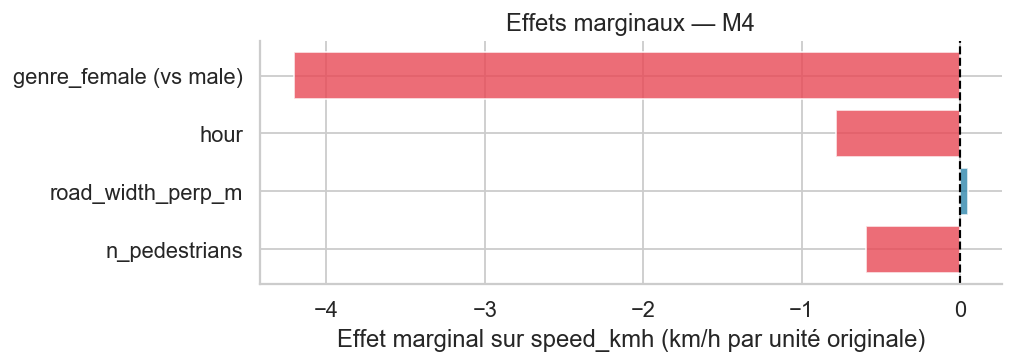

In [35]:
p4_betas = dict(zip(all_params['M4_full']['Name'],
                    all_params['M4_full']['Value'].astype(float)))

mu_val = p4_betas.get('MU', float(df_model['speed_kmh'].mean()))
print(f'Vitesse prédite à la moyenne : {mu_val:.2f} km/h')
print(f'Vitesse observée moyenne     : {df_model["speed_kmh"].mean():.2f} km/h')

var_map = {
    'beta_z_n_pedestrians':     ('n_pedestrians',     'piéton(s)'),
    'beta_z_road_width_perp_m': ('road_width_perp_m', 'mètre(s)'),
    'beta_z_hour':              ('hour',              'heure(s)'),
}

me_rows = []
for bname, (raw_name, unit) in var_map.items():
    beta_z = p4_betas.get(bname, float('nan'))
    sd     = stds_.get(raw_name, float('nan'))
    me_per_unit = beta_z / sd
    me_rows.append({
        'Variable':        raw_name,
        'beta_z (km/h/σ)': round(beta_z, 4),
        'ME (km/h/unité)': round(me_per_unit, 5),
        'Unité':           unit,
    })

# Genre (dummy)
beta_genre = p4_betas.get('beta_genre_female', float('nan'))
me_rows.append({
    'Variable':        'genre_female (vs male)',
    'beta_z (km/h/σ)': round(beta_genre, 4),
    'ME (km/h/unité)': round(beta_genre, 4),
    'Unité':           'dummy',
})

me_df = pd.DataFrame(me_rows)
print('\nEffets marginaux — M4 :')
display(me_df)

fig, ax = plt.subplots(figsize=(8, 3))
vals_me = me_df['ME (km/h/unité)'].tolist()
labs_me = me_df['Variable'].tolist()
cols_me = [COLOR_A if v >= 0 else COLOR_B for v in vals_me]
ax.barh(labs_me, vals_me, color=cols_me, alpha=0.8)
ax.axvline(0, color='black', lw=1.2, ls='--')
ax.set_xlabel('Effet marginal sur speed_kmh (km/h par unité originale)')
ax.set_title('Effets marginaux — M4')
plt.tight_layout()
plt.show()

## 16 · Courbes de prédiction (M4)

Chaque graphique fait varier **une variable** sur son étendue (p2–p98),
toutes les autres maintenues à leur moyenne (z = 0).

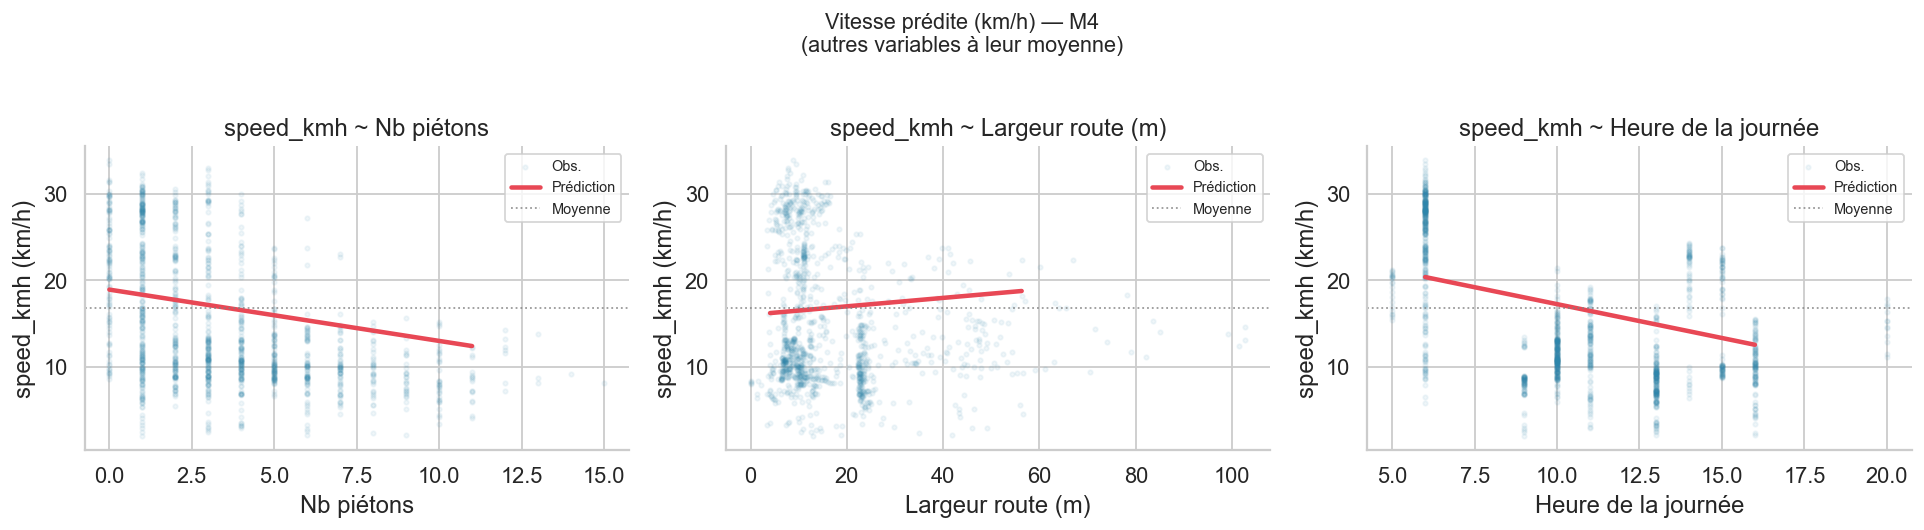

In [ ]:
vars_plot = [
    ('beta_z_n_pedestrians',     'n_pedestrians',     'Nb piétons'),
    ('beta_z_road_width_perp_m', 'road_width_perp_m', 'Largeur route (m)'),
    ('beta_z_hour',              'hour',              'Heure de la journée'),
]

fig, axes = plt.subplots(1, len(vars_plot), figsize=(5 * len(vars_plot), 4))

for ax, (beta_key, raw_var, label) in zip(axes, vars_plot):
    if raw_var not in means_ or raw_var not in stds_:
        ax.set_title(f'{label} — données manquantes')
        continue
    x_raw = np.linspace(df_model[raw_var].quantile(0.02),
                         df_model[raw_var].quantile(0.98), 200)
    x_z   = (x_raw - means_[raw_var]) / stds_[raw_var]
    beta_val = p4_betas.get(beta_key, 0.0)
    y_pred   = mu_val + beta_val * x_z

    ax.scatter(df_model[raw_var], df_model['speed_kmh_t1'],
               alpha=0.07, s=6, color=COLOR_A, label='Obs.')
    ax.plot(x_raw, y_pred, color=COLOR_B, lw=2.5, label='Prédiction')
    ax.axhline(mu_val, color='gray', lw=1, ls=':', alpha=0.8, label='Moyenne')
    ax.set_xlabel(label)
    ax.set_ylabel('speed_kmh (km/h)')
    ax.set_title(f'speed_kmh ~ {label}')
    ax.legend(fontsize=8)

plt.suptitle('Vitesse prédite (km/h) — M4\n(autres variables à leur moyenne)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 17 · Diagnostic des résidus (M4)

Vérification des hypothèses du modèle linéaire gaussien :
1. **Normalité** des résidus
2. **Homoscédasticité** (résidus vs valeurs prédites)
3. **R² et RMSE** classiques

R² (OLS) — M4 : 0.4261
RMSE — M4      : 5.754 km/h


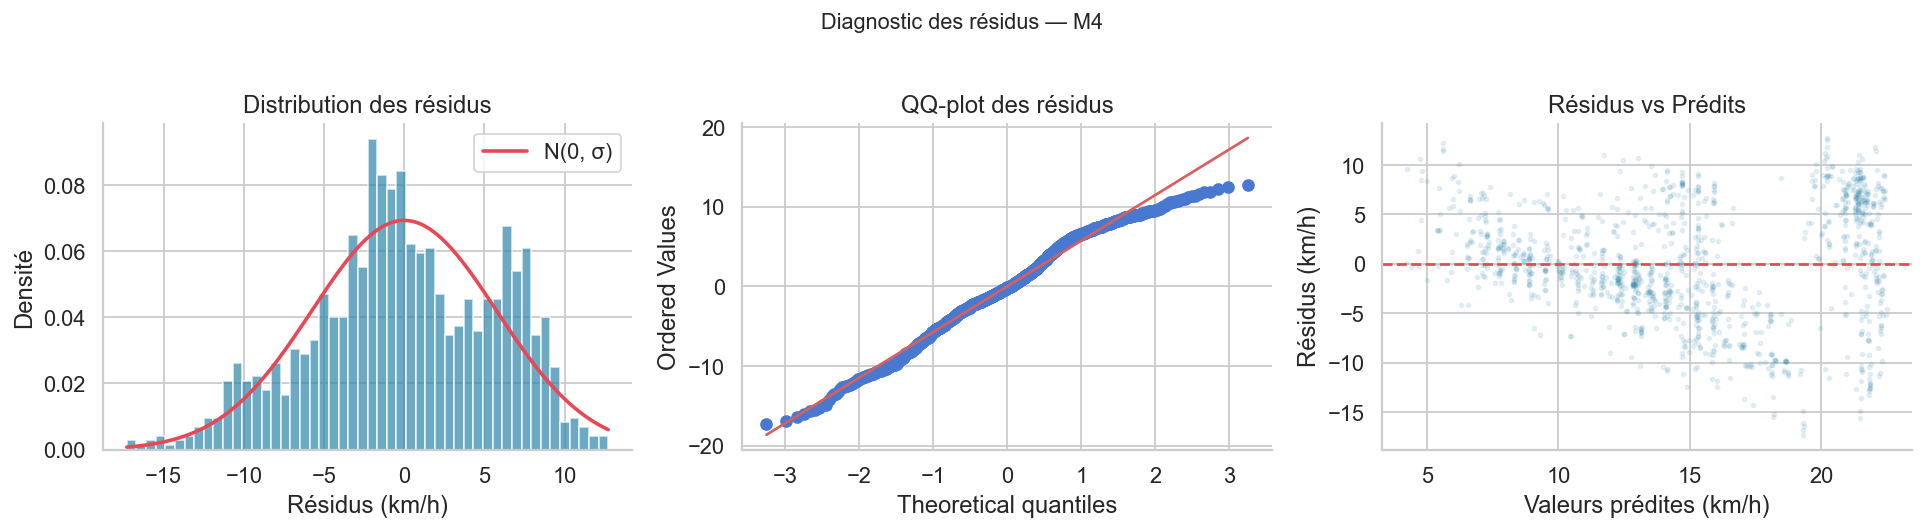


Test Shapiro-Wilk (n=1205) : stat=0.9855, p=1.3380e-09
H0 : résidus normaux


In [37]:
# Calcul des valeurs prédites et résidus pour M4
cols_m4 = ['speed_kmh', 'z_n_pedestrians', 'z_road_width_perp_m', 'z_hour', 'genre_female']
cols_m4 = [c for c in cols_m4 if c in df_model.columns]
data_m4 = df_model[cols_m4].dropna().copy()

y_pred_m4 = pd.Series(mu_val, index=data_m4.index)

for bname, col in [
    ('beta_z_n_pedestrians',     'z_n_pedestrians'),
    ('beta_z_road_width_perp_m', 'z_road_width_perp_m'),
    ('beta_z_hour',              'z_hour'),
    ('beta_genre_female',        'genre_female'),
]:
    if col in data_m4.columns and bname in p4_betas:
        y_pred_m4 = y_pred_m4 + p4_betas[bname] * data_m4[col]

residuals = data_m4['speed_kmh'] - y_pred_m4

ss_res = (residuals ** 2).sum()
ss_tot = ((data_m4['speed_kmh'] - data_m4['speed_kmh'].mean()) ** 2).sum()
r2_ols = 1 - ss_res / ss_tot
rmse   = np.sqrt(ss_res / len(residuals))
print(f'R² (OLS) — M4 : {r2_ols:.4f}')
print(f'RMSE — M4      : {rmse:.3f} km/h')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Histogramme + courbe normale
ax = axes[0]
ax.hist(residuals, bins=50, color=COLOR_A, alpha=0.7, density=True)
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
ax.plot(x_norm, stats.norm.pdf(x_norm, 0, residuals.std()),
        color=COLOR_B, lw=2, label='N(0, σ)')
ax.set_xlabel('Résidus (km/h)')
ax.set_ylabel('Densité')
ax.set_title('Distribution des résidus')
ax.legend()

# 2. QQ-plot
ax = axes[1]
stats.probplot(residuals, dist='norm', plot=ax)
ax.set_title('QQ-plot des résidus')

# 3. Résidus vs valeurs prédites
ax = axes[2]
ax.scatter(y_pred_m4, residuals, alpha=0.1, s=5, color=COLOR_A)
ax.axhline(0, color=COLOR_B, lw=1.5, ls='--')
ax.set_xlabel('Valeurs prédites (km/h)')
ax.set_ylabel('Résidus (km/h)')
ax.set_title('Résidus vs Prédits')

plt.suptitle('Diagnostic des résidus — M4', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Test de normalité (Shapiro-Wilk sur sous-échantillon)
n_test = min(5000, len(residuals))
sw_stat, sw_p = stats.shapiro(residuals.sample(n_test, random_state=42))
print(f'\nTest Shapiro-Wilk (n={n_test}) : stat={sw_stat:.4f}, p={sw_p:.4e}')
print('H0 : résidus normaux')

## 18 · Visualisation comparaison des modèles

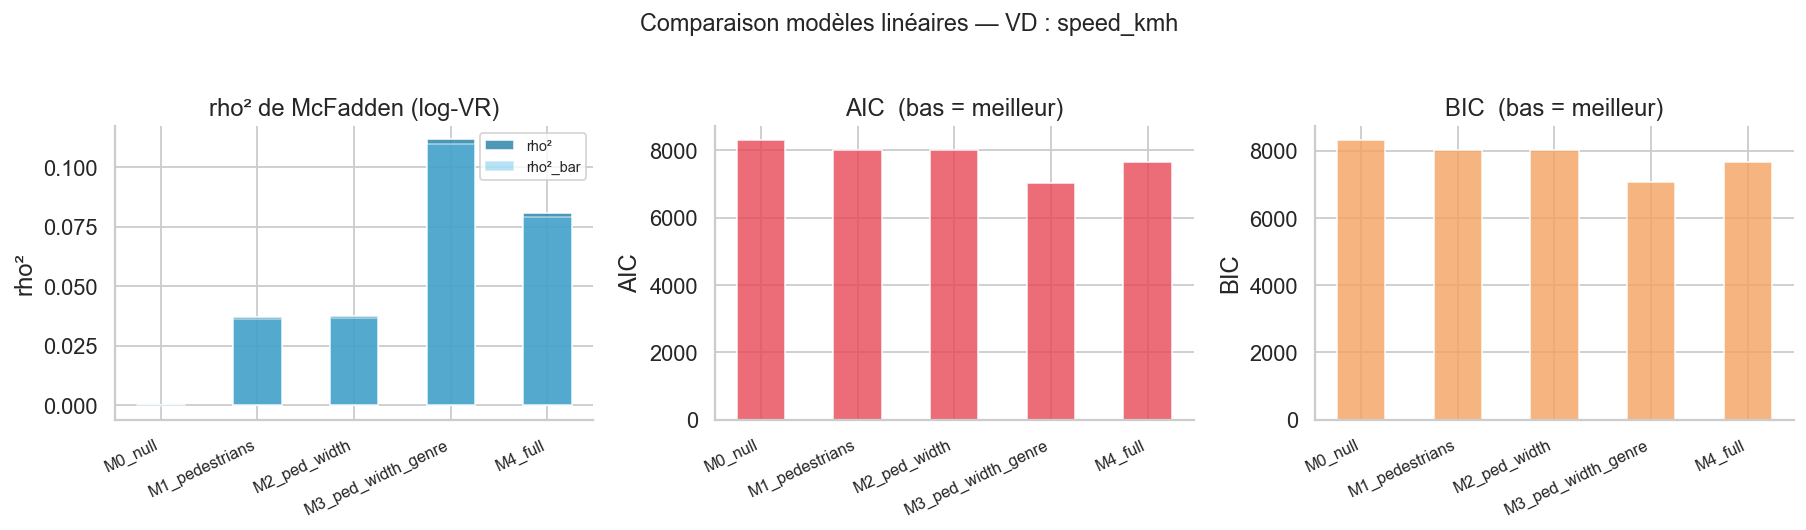

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
mnames = comparison.index.tolist()
x = np.arange(len(mnames))

ax = axes[0]
ax.bar(x, comparison['rho2'],     width=0.5, color=COLOR_A, alpha=0.85, label='rho²')
ax.bar(x, comparison['rho2_bar'], width=0.5, color='#5BC0EB', alpha=0.45, label='rho²_bar')
ax.set_xticks(x)
ax.set_xticklabels(mnames, rotation=25, ha='right', fontsize=9)
ax.set_title('rho² de McFadden (log-VR)')
ax.set_ylabel('rho²')
ax.legend(fontsize=8)

ax = axes[1]
ax.bar(x, comparison['AIC'], width=0.5, color=COLOR_B, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(mnames, rotation=25, ha='right', fontsize=9)
ax.set_title('AIC  (bas = meilleur)')
ax.set_ylabel('AIC')

ax = axes[2]
ax.bar(x, comparison['BIC'], width=0.5, color='#F4A261', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(mnames, rotation=25, ha='right', fontsize=9)
ax.set_title('BIC  (bas = meilleur)')
ax.set_ylabel('BIC')

plt.suptitle('Comparaison modèles linéaires — VD : speed_kmh', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 19 · Synthèse & prochaines étapes

### Lecture des coefficients

| Signe beta | Interprétation |
|------------|----------------|
| beta > 0 | la variable est **associée à une vitesse plus élevée** |
| beta < 0 | la variable est **associée à une vitesse plus faible** |

**Unité :** les coefficients sur les z-scores = **km/h par écart-type** de la variable.

### Comparaison avec l'ancien notebook logit

| Aspect | Logit (delta_speed) | **Linéaire (speed_kmh)** |
|--------|--------------------|--------------------------|
| Variable dépendante | Binaire acc/déc | **Continue (vitesse km/h)** |
| Perte d'information | Oui (seuil 0) | **Non** |
| Interprétation coeff | Log-odds | **km/h directement** |
| Hypothèse sur les erreurs | Logistique | **Normale** |
| R² | McFadden | **R² classique + McFadden** |

### Pistes d'extension

1. **Effets fixes trajets** : ajouter une dummy par trajet pour contrôler l'hétérogénéité conducteur
2. **Interaction** `z_n_ped × z_road_width` : la densité piétonne dépend-elle de la largeur de voie ?
3. **Régression mixte (LME)** via `statsmodels.formula.api.mixedlm` pour les effets aléatoires par trajet
4. **Validation** : split train/test par trajet, RMSE, MAE sur données de test